# **JPN225 OHLCV Index Analysis**

## **What This Code Does**

| Visualization | Description |
| :--- | :--- |
| **Chart 1 - Main View** | Price chart with anomaly markers (colored by severity), 20-day MA, and volatility bands |
| **Chart 2 - Returns** | Daily returns bar chart with anomalies highlighted |
| **Chart 3 - Volume** | Volume chart showing abnormal volume on anomaly days |
| **Detailed Report** | Table showing all anomalies with key metrics |
| **Score Distribution** | Shows severity levels and most common anomaly types |
| **Candlestick Zoom** | Detailed view around the most anomalous day |

---

## **Key Features of the Visualization**

1. **Color-coded anomalies**:
   - 🟡 Gold = Score 1-2 (Minor)
   - 🟠 Orange = Score 3-4 (Moderate)
   - 🔴 Red = Score 5-7 (Severe)

2. **Interactive annotations** showing anomaly scores

3. **Context bands** (20-day MA and ±2σ volatility bands)

4. **Multi-panel view** showing price, returns, and volume together

5. **Zoom-in on worst anomaly** with candlestick-like visualization


The visualization will clearly show you **exactly which days** had abnormal price movements and **why** they were flagged.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load data
df = pd.read_csv('/kaggle/input/datasets/getdatafinance/jpn225-3d-ohlcv-index-historical-data/JPN225_3d.csv')
#df=df.iloc[1:]
df.columns=['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

In [2]:
# Convert Date to datetime and sort
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# --- FILTER: Keep only the most recent 2 year ---
latest_date = df['Date'].max()
two_year_ago = latest_date - pd.DateOffset(years=2)
df_recent = df[df['Date'] >= two_year_ago].copy()

print("=" * 60)
print("DATA FILTER SUMMARY")
print("=" * 60)
print(f"Full dataset date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total records in full dataset: {len(df):,}")
print(f"Latest 2-year date range: {df_recent['Date'].min()} to {df_recent['Date'].max()}")
print(f"Records in latest 2 year: {len(df_recent):,}")
print("=" * 60)
print()

DATA FILTER SUMMARY
Full dataset date range: 2026-04-23 00:00:00+00:00 to 2026-07-31 00:00:00+00:00
Total records in full dataset: 72
Latest 2-year date range: 2026-04-23 00:00:00+00:00 to 2026-07-31 00:00:00+00:00
Records in latest 2 year: 72



In [3]:
def detect_stock_anomalies(df, date_col='Date', open_col='Open', high_col='High', 
                           low_col='Low', close_col='Close', adj_close_col='Adj Close', 
                           volume_col='Volume', 
                           lookback=20, vol_multiplier=2.0, gap_threshold=0.03, 
                           range_multiplier=1.5, iqr_multiplier=1.5, 
                           volume_multiplier=2.0, min_anomaly_score=2):
    
    # --- Ensure numeric types ---
    cols_to_convert = [open_col, high_col, low_col, close_col, volume_col]
    for col in cols_to_convert:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    df = df.copy()
    
    # --- Calculate Base Metrics ---
    df['return'] = df[close_col].pct_change()
    df['gap'] = (df[open_col] - df[close_col].shift(1)) / df[close_col].shift(1)
    df['range'] = df[high_col] - df[low_col]
    df['range_pct'] = df['range'] / df[close_col].shift(1)
    df['volume_ma'] = df[volume_col].rolling(lookback).mean()
    
    # --- Rolling statistics ---
    df['volatility'] = df['return'].rolling(lookback).std()
    df['avg_range'] = df['range'].rolling(lookback).mean()
    df['avg_range_pct'] = df['range_pct'].rolling(lookback).mean()
    
    # --- Calculate Scores ---
    df['score_vol'] = (abs(df['return']) > df['volatility'] * vol_multiplier).astype(int)
    df['score_gap'] = (abs(df['gap']) > gap_threshold).astype(int)
    df['score_range'] = (df['range'] > df['avg_range'] * range_multiplier).astype(int)
    
    # --- IQR Outlier ---
    q1 = df['return'].rolling(60).quantile(0.25)
    q3 = df['return'].rolling(60).quantile(0.75)
    iqr = q3 - q1
    df['score_iqr'] = (
        (df['return'] > q3 + iqr_multiplier * iqr) | 
        (df['return'] < q1 - iqr_multiplier * iqr)
    ).astype(int)
    
    # --- Volume & Trends ---
    df['score_volume'] = (df[volume_col] > df['volume_ma'] * volume_multiplier).astype(int)
    
    df['trend_5d'] = df[close_col].pct_change(5)
    df['score_reversal'] = (
        ((df['trend_5d'] > 0.05) & (df['return'] < -0.02)) |
        ((df['trend_5d'] < -0.05) & (df['return'] > 0.02))
    ).astype(int)
    
    df['score_gap_volume'] = (
        (abs(df['gap']) > 0.03) & 
        (df[volume_col] > df['volume_ma'] * 2.0)
    ).astype(int)
    
    # --- Aggregate ---
    score_columns = [
        'score_vol', 'score_gap', 'score_range', 'score_iqr',
        'score_volume', 'score_reversal', 'score_gap_volume'
    ]
    df['anomaly_score'] = df[score_columns].sum(axis=1)
    df['is_anomaly'] = df['anomaly_score'] >= min_anomaly_score
    
    return df

In [4]:
# ============================================================
# Detect Anomalies - This adds all columns to df_recent
# ============================================================
# Pass the lookback value (e.g., 20) as an argument
df_recent = detect_stock_anomalies(df_recent, lookback=20)
anomalies = df_recent[df_recent['is_anomaly']].copy()
anomalies = anomalies.sort_values('anomaly_score', ascending=False)

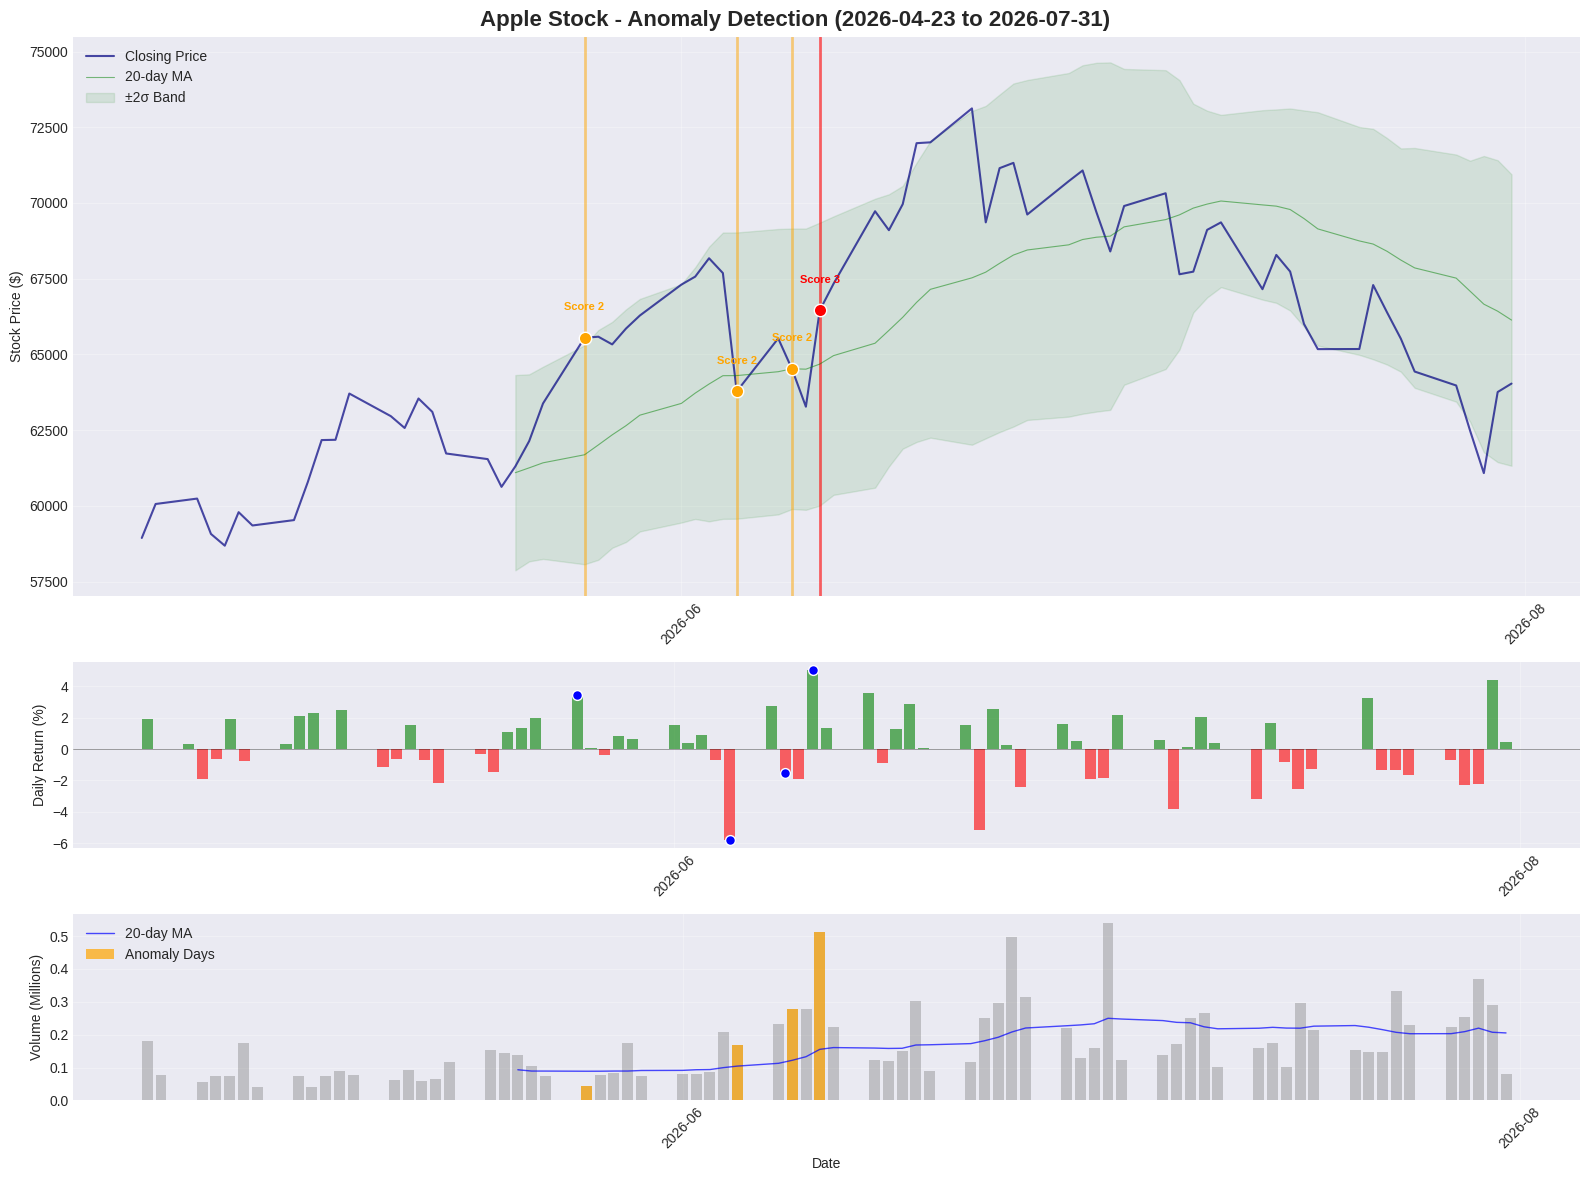

In [5]:
# ============================================================
# VISUALIZATION 1: Price Chart with Anomaly Markers
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [3, 1, 1]})
fig.suptitle(f'Apple Stock - Anomaly Detection ({df_recent["Date"].min().strftime("%Y-%m-%d")} to {df_recent["Date"].max().strftime("%Y-%m-%d")})', 
             fontsize=16, fontweight='bold')

# --- Plot 1: Price with Anomaly Markers ---
ax1 = axes[0]

# Plot price line
ax1.plot(df_recent['Date'], df_recent['Close'], linewidth=1.5, color='navy', alpha=0.7, label='Closing Price')

# Highlight anomalies with different colors based on score
if len(anomalies) > 0:
    # Define color mapping for anomaly scores
    score_colors = {
        1: 'gold',
        2: 'orange',
        3: 'red',
        4: 'darkred',
        5: 'purple',
        6: 'darkviolet',
        7: 'black'
    }
    
    # Plot each anomaly as a vertical line with color based on score
    for idx, row in anomalies.iterrows():
        color = score_colors.get(min(row['anomaly_score'], 7), 'red')
        alpha = min(0.3 + (row['anomaly_score'] / 10), 0.9)
        
        # Vertical line from top to bottom of the plot
        ax1.axvline(x=row['Date'], color=color, alpha=alpha, linewidth=2)
        
        # Scatter point on the price line
        ax1.scatter(row['Date'], row['Close'], color=color, s=80, zorder=5, 
                   edgecolors='white', linewidth=1)
        
        # Add score annotation
        ax1.annotate(f'Score {int(row["anomaly_score"])}', 
                    xy=(row['Date'], row['Close']),
                    xytext=(0, 20), 
                    textcoords='offset points',
                    fontsize=8,
                    color=color,
                    fontweight='bold',
                    ha='center')

# Add mean and volatility bands (optional)
rolling_mean = df_recent['Close'].rolling(20).mean()
rolling_std = df_recent['Close'].rolling(20).std()

ax1.plot(df_recent['Date'], rolling_mean, color='green', linewidth=0.8, alpha=0.5, label='20-day MA')
ax1.fill_between(df_recent['Date'], 
                 rolling_mean - 2*rolling_std, 
                 rolling_mean + 2*rolling_std, 
                 color='green', alpha=0.1, label='±2σ Band')

ax1.set_ylabel('Stock Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Format x-axis dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.tick_params(axis='x', rotation=45)

# --- Plot 2: Daily Returns with Anomaly Highlight ---
ax2 = axes[1]

# Now df_recent has the 'return' column
colors = ['green' if x >= 0 else 'red' for x in df_recent['return'].fillna(0)]
ax2.bar(df_recent['Date'], df_recent['return'] * 100, color=colors, alpha=0.6, width=0.8)

# Highlight anomalous returns
if len(anomalies) > 0:
    anomaly_returns = anomalies[['Date', 'return']].dropna()
    ax2.scatter(anomaly_returns['Date'], anomaly_returns['return'] * 100, 
               color='blue', s=50, zorder=5, edgecolors='white', linewidth=1)

# Add horizontal line at 0
ax2.axhline(y=0, color='black', linewidth=0.5, alpha=0.5)

ax2.set_ylabel('Daily Return (%)')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.tick_params(axis='x', rotation=45)

# --- Plot 3: Volume with Anomaly Highlight ---
ax3 = axes[2]

# Plot volume bars
ax3.bar(df_recent['Date'], df_recent['Volume'] / 1e6, color='gray', alpha=0.4, width=0.8)

# Highlight volume on anomalous days
if len(anomalies) > 0:
    anomaly_volume = anomalies[['Date', 'Volume']].dropna()
    ax3.bar(anomaly_volume['Date'], anomaly_volume['Volume'] / 1e6, 
            color='orange', alpha=0.7, width=0.8, label='Anomaly Days')

# Add volume moving average
volume_ma = df_recent['Volume'].rolling(20).mean()
ax3.plot(df_recent['Date'], volume_ma / 1e6, color='blue', linewidth=1, alpha=0.7, label='20-day MA')

ax3.set_ylabel('Volume (Millions)')
ax3.set_xlabel('Date')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# VISUALIZATION 2: Detailed Anomaly Report
# ============================================================

print("\n" + "=" * 60)
print("DETAILED ANOMALY REPORT")
print("=" * 60)

if len(anomalies) > 0:
    print(f"\nFound {len(anomalies)} anomalous days in the past year:")
    print("-" * 90)
    
    # Format for display
    display_df = anomalies[['Date', 'Close', 'return', 'gap', 'range_pct', 'Volume', 'anomaly_score']].copy()
    display_df['Date'] = display_df['Date'].dt.strftime('%Y-%m-%d')
    display_df['return'] = display_df['return'] * 100
    display_df['gap'] = display_df['gap'] * 100
    display_df['range_pct'] = display_df['range_pct'] * 100
    display_df['Volume'] = display_df['Volume'] / 1e6
    
    display_df.columns = ['Date', 'Close ($)', 'Return (%)', 'Gap (%)', 'Range (%)', 'Volume (M)', 'Score']
    print(display_df.head(10).to_string(index=False, float_format='%.2f'))
    
    if len(anomalies) > 10:
        print(f"\n... and {len(anomalies) - 10} more days")
    
    print("\n" + "-" * 90)
    print("Score Legend:")
    print("  1-2: Minor anomaly  |  3-4: Moderate anomaly  |  5-7: Severe anomaly")
    
else:
    print("No anomalies detected in the recent 2-year period.")


DETAILED ANOMALY REPORT

Found 4 anomalous days in the past year:
------------------------------------------------------------------------------------------
      Date  Close ($)  Return (%)  Gap (%)  Range (%)  Volume (M)  Score
2026-06-11   66452.49        5.02     0.00       6.74        0.51      3
2026-05-25   65550.24        3.42     0.00       3.72        0.05      2
2026-06-05   63778.07       -5.77     0.00       6.18        0.17      2
2026-06-09   64513.67       -1.55     0.00       4.60        0.28      2

------------------------------------------------------------------------------------------
Score Legend:
  1-2: Minor anomaly  |  3-4: Moderate anomaly  |  5-7: Severe anomaly


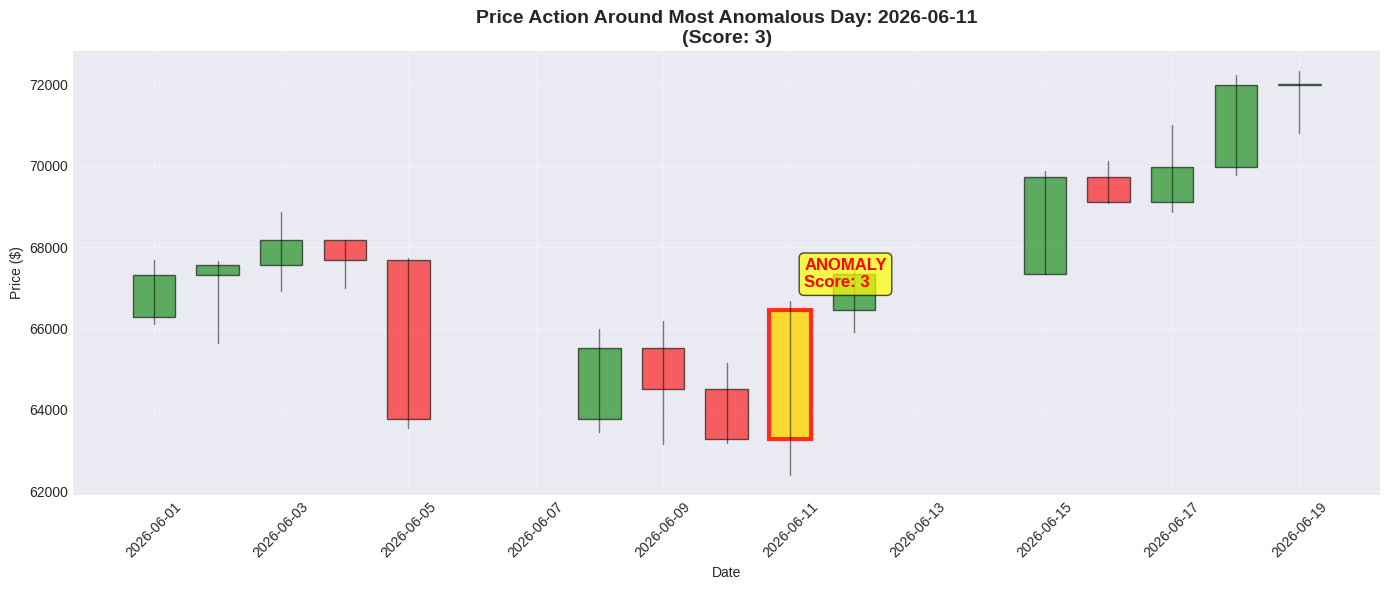


SUMMARY STATISTICS
Total trading days analyzed: 72
Anomalous days detected: 4
Anomaly rate: 5.56%
Average anomaly score: 2.25
Max anomaly score: 3
Min anomaly score: 2


In [7]:
# ============================================================
# VISUALIZATION 4: Zoom-in on Most Anomalous Day
# ============================================================

if len(anomalies) > 0:
    # Create a candlestick-like chart for the most anomalous week
    top_anomaly = anomalies.iloc[0]
    anomaly_date = top_anomaly['Date']
    
    # Get 10 days before and after
    start_date = anomaly_date - pd.DateOffset(days=10)
    end_date = anomaly_date + pd.DateOffset(days=10)
    window_data = df_recent[(df_recent['Date'] >= start_date) & (df_recent['Date'] <= end_date)].copy()
    
    if len(window_data) > 0:
        fig, ax = plt.subplots(figsize=(14, 6))
        
        # Plot candlestick-like bars (high-low lines with open-close boxes)
        for idx, row in window_data.iterrows():
            # Vertical line (high-low)
            ax.plot([row['Date'], row['Date']], [row['Low'], row['High']], 
                   color='black', linewidth=1, alpha=0.5)
            
            # Body (open-close)
            if row['Close'] >= row['Open']:
                color = 'green'
                bottom = row['Open']
                height = row['Close'] - row['Open']
            else:
                color = 'red'
                bottom = row['Close']
                height = row['Open'] - row['Close']
            
            # Highlight the anomaly day
            if row['Date'] == anomaly_date:
                rect = Rectangle((row['Date'] - pd.Timedelta(hours=8), bottom), 
                                pd.Timedelta(hours=16), height,
                                facecolor='gold', edgecolor='red', linewidth=3, alpha=0.8)
                ax.add_patch(rect)
                
                # Add annotation
                ax.annotate(f'ANOMALY\nScore: {int(row["anomaly_score"])}', 
                           xy=(row['Date'], row['High']),
                           xytext=(10, 10), 
                           textcoords='offset points',
                           fontsize=12,
                           fontweight='bold',
                           color='red',
                           bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))
            else:
                rect = Rectangle((row['Date'] - pd.Timedelta(hours=8), bottom), 
                                pd.Timedelta(hours=16), height,
                                facecolor=color, edgecolor='black', linewidth=1, alpha=0.6)
                ax.add_patch(rect)
        
        # Formatting
        ax.set_title(f'Price Action Around Most Anomalous Day: {anomaly_date.strftime("%Y-%m-%d")}\n(Score: {int(top_anomaly["anomaly_score"])})', 
                    fontsize=14, fontweight='bold')
        ax.set_ylabel('Price ($)')
        ax.set_xlabel('Date')
        ax.grid(True, alpha=0.3)
        
        # Format x-axis
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()


# ============================================================
# Summary Statistics
# ============================================================

print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"Total trading days analyzed: {len(df_recent):,}")
print(f"Anomalous days detected: {len(anomalies):,}")
print(f"Anomaly rate: {len(anomalies)/len(df_recent)*100:.2f}%")
print(f"Average anomaly score: {anomalies['anomaly_score'].mean():.2f}")
print(f"Max anomaly score: {anomalies['anomaly_score'].max()}")
print(f"Min anomaly score: {anomalies['anomaly_score'].min()}")



## Background of the Sudden Crash on June 5 and the Sharp Rebound on June 11, 2026

In early June 2026, the Nikkei 225 index experienced extreme volatility due to a combination of **adjustments in US tech stocks, escalating Middle East geopolitical tensions, and speculation surrounding Bank of Japan (BOJ) monetary policy.**

Here are the detailed backgrounds and key drivers behind each movement:

---

### 1. Background of the June 5 Crash

On June 5, the Tokyo market opened significantly lower, with the Nikkei 225 plummeting **by over 1,500 to 1,600 yen during intraday trading** (closing down 882 yen at 66,588 yen).

* **Plunge in US Tech & Semiconductor Stocks (Immediate Trigger)**
In the preceding US trading session, Nasdaq and semiconductor-related shares faced heavy selling pressure following disappointing earnings reports (e.g., Broadcom) and prolonged interest rate concerns stemming from stronger-than-expected May US employment data.
* **Profit-Taking on Japanese AI & Semiconductor Leaders**
Heavy profit-taking concentrated on major high-tech stocks that had previously driven the market rally, including Tokyo Electron, Advantest, Lasertec, and Fujikura.
* **Geopolitical Risks & Domestic Rate Speculation**
Heightened geopolitical tensions in the Middle East induced a risk-off sentiment. Additionally, speculation regarding a potential BOJ interest rate hike at its June policy meeting weighed heavily on market sentiment.

---

### 2. Background of the June 11 V-Shaped Rebound (Morning Drop to Sharp Rally)

On June 11, the market took a dramatic rollercoaster ride, **rebounding sharply from an early loss of over 1,800 yen to close in positive territory.**

* **Cause of the Morning Plunge: Escalating Middle East / Iran Tensions**
Declines in US equities overnight and worsening geopolitical tensions in the Middle East (particularly involving Iran) triggered panic selling at the market open, dropping the index by more than 1,800 yen.
* **Cause of the Rebound: Strong Bargain Hunting & Short Covering**
Once short-term overbought conditions were cleared, institutional investors and futures traders stepped in to buy back beaten-down AI and semiconductor stocks, seeing attractive entry prices.
* **Rally in Heavyweight Tech Stocks**
A swift recovery in key high-tech stocks with high index weightings—backed by surging trading volume—lifted the overall index through the close, ultimately ending slightly in positive territory (up 38 yen at 64,217 yen).

---

### Key Summary

| Date | Market Movement | Primary Drivers |
| --- | --- | --- |
| **June 5** | Intraday drop of over 1,500 yen | US tech sell-off, high US interest rate fears, profit-taking in Japanese AI/semiconductor stocks due to BOJ rate hike speculation. |
| **June 11** | Sharp reversal from a 1,800+ yen loss to a positive close | Morning panic selling over Middle East tensions followed by aggressive bargain hunting and short covering in oversold tech stocks. |